# Clustering sequentially with agglomerative hierarchial clustering (AHC) and dynamic time warping (DTW)

__author__ = "Rahul Kakodkar"
__copyright__ = "Copyright 2022, Multi-parametric Optimization & Control Lab"
__credits__ = ["Rahul Kakodkar", "Efstratios N. Pistikopoulos"]
__license__ = "Open"
__version__ = "1.0.0"
__maintainer__ = "Rahul Kakodkar"
__email__ = "cacodcar@tamu.edu"
__status__ = "Production"


$\textbf{Import modules}$

In [1]:
import pandas 
from numpy import poly1d, polyfit, arange
from src.energiapy.components.temporal_scale import Temporal_scale
from src.energiapy.components.resource import Resource
from src.energiapy.components.process import Process
from src.energiapy.components.material import Material
from src.energiapy.components.location import Location
from src.energiapy.components.network import Network
from src.energiapy.components.scenario import Scenario
from src.energiapy.components.transport import Transport
from src.energiapy.components.result import Result 
from src.energiapy.model.formulate_milp import formulate_milp
from src.energiapy.utils.data_utils import get_data, make_henry_price_df
from src.energiapy.utils.nsrdb_utils import fetch_nsrdb_data
from src.energiapy.plot import plot
from src.energiapy.model.pyomo_solve import solve
from src.energiapy.utils.cluster_utils import reduce_scenario, agg_hierarchial_elbow, Clustermethod, dynamic_warping, dynamic_warping_path
from src.energiapy.utils.data_utils import load_results
import matplotlib.pyplot as plt
from matplotlib import rc
from itertools import product

**Import solar dni and wind speeds for Harris county**


In [2]:
weather20_df = pandas.read_csv('data/ho_solar20.csv', index_col=0)
weather20_df.index = [i.split('+')[0] for i in weather20_df.index]
weather19_df = pandas.read_csv('data/ho_solar19.csv', index_col=0)
weather18_df = pandas.read_csv('data/ho_solar18.csv', names = ['wind_speed', 'dni'])
weather17_df = pandas.read_csv('data/ho_solar17.csv', index_col=0)
weather16_df = pandas.read_csv('data/ho_solar16.csv', index_col=0)
weather15_df = pandas.read_csv('data/ho_solar15.csv', index_col=0)
weather_df_wl = pandas.concat([weather16_df, weather17_df, weather18_df, weather19_df, weather20_df])
weather_df = weather_df_wl[~weather_df_wl.index.str.contains('02-29')] #remove leap years

**Demand data from ERCOT**

In [3]:
ercot20 = pandas.read_excel('data/Native_Load_2020.xlsx')
ercot19 = pandas.read_excel('data/Native_Load_2019.xlsx')
ercot18 = pandas.read_excel('data/Native_Load_2018.xlsx')
ercot17 = pandas.read_excel('data/Native_Load_2017.xlsx')
ercot16 = pandas.read_excel('data/Native_Load_2016.xlsx')
ercot = pandas.DataFrame(pandas.concat([ercot16['COAST'], ercot17['COAST'], ercot18['COAST'], ercot19['COAST'], ercot20['COAST']]))
ercot['index'] = weather_df_wl.index
# ercot = ercot.drop(columns= 'HourEnding')
ercot = ercot.set_index('index')
# ercot = ercot[['COAST']]
ercot = ercot[~ercot.index.str.contains('02-29')]
ercot.loc['2016-11-06 23:00:00'] = ercot.loc['2016-11-06 22:00:00'] #random missing data which gave a fucking

**Import natural gas prices from Henry Hub Price Index**  

In [4]:
ng_price20 = make_henry_price_df(
    file_name='data/Henry_Hub_Natural_Gas_Spot_Price_Daily.csv', year=2020, stretch=False)
ng_price19 = make_henry_price_df(
    file_name='data/Henry_Hub_Natural_Gas_Spot_Price_Daily.csv', year=2019, stretch=False)
ng_price18 = make_henry_price_df(
    file_name='data/Henry_Hub_Natural_Gas_Spot_Price_Daily.csv', year=2018, stretch=False)
ng_price17 = make_henry_price_df(
    file_name='data/Henry_Hub_Natural_Gas_Spot_Price_Daily.csv', year=2017, stretch=False)
ng_price16 = make_henry_price_df(
    file_name='data/Henry_Hub_Natural_Gas_Spot_Price_Daily.csv', year=2016, stretch=False)
ng_price_df = pandas.concat([ng_price16, ng_price17, ng_price18, ng_price19, ng_price20])
ng_price_df['index'] = [i for i in weather_df.index][::24]
ng_price_df = ng_price_df.drop(columns= 'scales')
ng_price_df = ng_price_df.set_index('index')


**import cost data**


In [5]:
cost_dict = get_data(file_name='data/cost_dict')
for i in cost_dict['HO']['moderate'].keys():
    print(i + ':', cost_dict['HO']['moderate'][i]['0'])

LiI_c: {'CAPEX': 1302181.81818181, 'Fixed O&M': 41432.7272727272, 'Variable O&M': 0, 'units': '$/MW', 'source': 'NREL Annual Technology Baseline 2021, https://atb.nrel.gov/'}
LiI_d: {'CAPEX': 0.001, 'Fixed O&M': 0.001, 'Variable O&M': 0, 'units': '$/MW', 'source': 'Dummy Process'}
CAES_c: {'CAPEX': 1669000.0, 'Fixed O&M': 16700.0, 'Variable O&M': 0, 'units': '$/MW', 'source': 'https://www.pnm.com/documents/396023/1506047/2017+-+HDR+10-30-17+PNM+Energy+Storage+Report.pdf/a2b7ca65-e1ba-92c8-308a-9a8391a87331'}
CAES_d: {'CAPEX': 0.001, 'Fixed O&M': 0.001, 'Variable O&M': 0, 'units': '$/MW', 'source': 'Dummy Process'}
PSH_c: {'CAPEX': 0, 'Fixed O&M': 41432.7272727272, 'Variable O&M': 4435.188, 'units': '$/MW', 'source': 'NREL Annual Technology Baseline 2021, https://atb.nrel.gov/'}
PSH_d: {'CAPEX': 0.001, 'Fixed O&M': 0.001, 'Variable O&M': 0, 'units': '$/MW', 'source': 'Dummy Process'}
PV: {'CAPEX': 1302181.81818181, 'Fixed O&M': 41432.7272727272, 'Variable O&M': 0, 'units': '$/MW', 'sour

$\textbf{Define temporal scale}$


In [6]:
scales = Temporal_scale(discretization_list=[5, 365, 24], start_zero= 2016)

$\textbf{Declare constants for ease}$


In [7]:
bigM = 10**4  # very large number
smallM = 0.1
water_price = 31.70  # $/5000gallons
power_price = 8  # cents/kWh
ur_price = 42.70  # 250 Pfund U308 (Uranium)
A_f = 0.05  # annualization factor
# CO2_res = 0.2
pv_start = 0
ake_start = 0
smrh_start = 0
smr_start = 0
asmr_start = 0

$\textbf{Declare resources}$

In [8]:
Charge = Resource(name='Charge', sell=False,
                  store_max=100, basis='MW', label='Battery energy', block='energystorage')

Air_C = Resource(name='Air_C', store_max=bigM, basis='MW',
                 label='CAES energy', block='energystorage')

H2O_E = Resource(name='H2O_E', store_max=bigM, basis='MW',
                 label='PSH energy', block='energystorage')

Uranium = Resource(name='Uranium', cons_max=(1/4.17*10**(-5))*bigM,
                   price=ur_price/(250/2), basis='kg', label='Uranium', block='energyfeedstock')

Solar = Resource(
    name='Solar', cons_max=bigM, basis='MW', label='Solar Power', block='energyfeedstock')

Wind = Resource(name='Wind', cons_max= bigM, basis='MW', label='Wind Power', block='energyfeedstock')

H2_L = Resource(name='H2_L', store_max=10**10, revenue=2,
                mile=1/(0.1180535*1.60934), basis='kg', label='Hydrogen - Geological', block='resourcestorage')

H2_C = Resource(name='H2_C', store_max= 10**10, loss=0.025/24, revenue=2, mile=1/(0.1180535*1.60934), \
    basis='kg', label='Hydrogen - Local Cryo', block='resourcestorage')


# H2 = Resource(name='H2', basis='kg', sell = True, demand = True, label='Hydrogen', block='Resource')
H2 = Resource(name='H2', basis='kg', label='Hydrogen', block='Resource')


H2O = Resource(name='H2O', cons_max=10**10,
               price=water_price/(5000*3.7854), basis='kg', label='Water', block='Resource')
            
O2 = Resource(name='O2', sell=True, loss=0.07,
              basis='kg', label='Oxygen', block='Resource')


CH4 = Resource(name='CH4', cons_max=10 **
               10, price=0.113891, basis='kg', label='Natural gas', block='materialfeedstock')

CO2 = Resource(name='CO2', basis='kg',
               label='Carbon dioxide', block='Resource')


CO2_DAC = Resource(
    name='CO2_DAC', basis='kg', label='Carbon dioxide - captured', block='carbonsequestration')

CO2_AQoff = Resource(
    name='CO2_AQoff', store_max=10**6, basis='kg', label='Carbon dioxide - sequestered', block='carbonsequestration')

CO2_EOR = Resource(
    name='CO2_EOR', store_max=10**6, basis='kg', label='Carbon dioxide - EOR', block='carbonsequestration')


CH3OH = Resource(name='CH3OH', sell=True, revenue=0.5,
                 mile=1/(0.0195508*1.60934), basis='kg', label='Methanol', block='resourcedischarge')

CO2_Vent = Resource(
    name='CO2_Vent', sell=True, basis='kg', label='Carbon dioxide - Vented', block='resourcedischarge')

# Power= Resource(name= 'Power', sell= True, store_max=0,   \
#    mile= (10**3)/(0.2167432**1.60934), label= 'Renewable power generated')

Power = Resource(name='Power', basis='MW',
                 label='Renewable power generated', block='Resource')

Mile = Resource(name = 'Mile', basis = 'miles', sell = True, demand  = True, label = 'miles driven')


$\textbf{Declare processes}$

In [9]:
LiI_c = Process(name='LiI_c', conversion={Charge: 1, Power: -1}, cost = cost_dict['HO']['moderate']['LiI_c']['0'],\
    prod_max=100, trl='nrel', block='power_storage', label='Lithium-ion battery', citation='Zakeri 2015')

LiI_d = Process(name='LiI_d', conversion={Charge: -1.1765, Power: 1}, cost =  {'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': smallM, \
    'units': '$/kg','source': 'dummy'}, \
    prod_max=100, trl='discharge', block='power_storage', label='Lithium-ion battery discharge', citation='Zakeri 2015')

CAES_c = Process(name='CAES_c', conversion={Air_C: 1, Power: -1}, cost = cost_dict['HO']['moderate']['CAES_c']['0'], \
    intro_scale=0, prod_max=bigM, trl='pilot', block='power_storage', label='Compressed air energy storage (CAES)', citation='Zakeri 2015')

CAES_d = Process(name='CAES_d', conversion={Air_C: -1.4286, Power: 1}, cost =  {'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': smallM, \
    'units': '$/kg','source': 'dummy'},\
    intro_scale=0, prod_max=bigM, trl='discharge', block='power_storage', label='Compressed air energy storage (CAES) discharge', citation='Zakeri 2015')

PSH_c = Process(name='PSH_c', conversion={H2O_E: 1, Power: -1}, cost = cost_dict['HO']['moderate']['PSH_c']['0'], \
    intro_scale=0, prod_max=bigM, trl='nrel', block='power_storage', label='Pumped storage hydropower (PSH)', citation='Zakeri 2015')

PSH_d = Process(name='PSH_d', conversion={H2O_E: -1.4286, Power: 1}, cost =  {'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': smallM, \
    'units': '$/kg','source': 'dummy'}, \
    prod_max=bigM, trl='discharge', block='power_storage', label='Pumped storage hydropower (PSH) discharge', citation='Zakeri 2015')

WF = Process(name='WF', conversion={Wind: -1, Power: 1, H2O: -1}, cost=cost_dict['HO']['moderate']['WF']['0'],
             prod_max=100, gwp=52700, land=10800/1800, trl='nrel', block='power_generation',
             label='Wind mill array', citation='Use windtoolkit conversion')

PV = Process(name='PV', intro_scale=pv_start, conversion={Solar: -1, Power: 1, H2O: -20}, cost=cost_dict['HO']['moderate']['PV']['0'],
             prod_max=100, gwp=53000, land=13320/1800, trl='nrel', block='power_generation', \
                 label='Solar photovoltaics (PV) array', citation='Use pvlib conversion')

AKE = Process(name='AKE', intro_scale=ake_start, conversion={Power: -1, H2: 19.474, O2: 763.2, H2O: -175.266},
              cost=cost_dict['HO']['moderate']['AKE']['0'], prod_max=bigM, trl='utility', block='material_production',
              label='Alkaline water electrolysis (AWE)', citation='Demirhan et al. 2018 AIChE paper')  # 20.833 MW required to produce 1000t/day.H2

SMRH = Process(name='SMRH', intro_scale=smrh_start, conversion={Power: -1.11*10**(-3), CH4: -3.76, H2O: -23.7, H2: 1, CO2_Vent: 1.03, CO2: 9.332},
               cost=cost_dict['HO']['moderate']['SMRH']['0'], prod_max=bigM, gwp=0, trl='enterprise', block='material_production',
               label='Steam methane reforming + CCUS', citation='Mosca 2020, 90pc capture')

SMR = Process(name='SMR', intro_scale=smr_start, cost= {'CAPEX': 2400, 'Fixed O&M': 800, 'Variable O&M': 0.03, 'units': '$/kg', 'source': 'dummy'}, \
    conversion={Power: -1.11*10**(-3), CH4: -3.76, H2O: -23.7, H2: 1, CO2_Vent: 9.4979}, prod_max=bigM, gwp=0, trl='enterprise',
                      block='material_production', label='Steam methane reforming', citation='Mosca 2020')

ASMR = Process(name='ASMR', conversion={Uranium: -4.17*10**(-5), H2O: -3364.1, Power: 1}, cost=cost_dict['HO']['moderate']['ASMR']['0'],
               intro_scale=asmr_start, gwp=9100, prod_max=bigM, land=1100/1800, trl='pilot', block='power_generation', label='Small modular reactors (SMRs)')

H2_C_c = Process(name='H2_C_c', conversion={Power: -1.10*10**(-3), H2_C: 1, H2: -1}, cost={'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': 0,
                                                                                           'units': '$/kg', 'source': 'dummy'},
                 prod_max=12000, gwp=0, trl='pilot', block='material_storage', label='Hydrogen local storage (Compressed)',
                 citation='Bossel and Eliasson - Energy and the Hydrogen Economy')

H2_C_d = Process(name='H2_C_d',  conversion={H2_C: -1, H2: 1}, cost={'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': 0,
                                                                     'units': '$/kg', 'source': 'dummy'},
                 prod_max=bigM, gwp=0, trl='nocost',
                 block='material_storage', label='Hydrogen local storage (Compressed) discharge', citation='Bossel and Eliasson - Energy and the Hydrogen Economy')

H2_L_c = Process(name='H2_L_c', conversion={Power: -4.17*10**(-4), H2_L: 1, H2: -1}, cost={'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': 0,
                                                                                           'units': '$/kg', 'source': 'dummy'},
                 prod_max=bigM, gwp=0, trl='repurposed', block='material_storage', label='Hydrogen geological storage',
                 citation='Bossel and Eliasson - Energy and the Hydrogen Economy')

H2_L_d = Process(name='H2_L_d', conversion={H2_L: -1, H2: 1}, prod_max=bigM, gwp=0, trl='nocost', cost={'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': 0,
                                                                                                        'units': '$/kg', 'source': 'dummy'},
                 block='material_storage', label='Hydrogen geological storage discharge', citation='Bossel and Eliasson - Energy and the Hydrogen Economy')

DAC = Process(name='DAC', conversion={Power: -1.93*10**(-4), H2O: -4.048, CO2_DAC: 1}, cost=cost_dict['HO']['moderate']['DAC']['0'],
              intro_scale=4, prod_max=bigM, gwp=0, trl='pilot', block='CCUS', label='Direct air capture', citation='D. Belloti et al (2017)')

EOR = Process(name='EOR', intro_scale=0, conversion={Power: -0.00255, CO2: -1, CO2_EOR: 1, CO2_Vent: 0.67},
              cost=cost_dict['HO']['moderate']['EOR']['0'], prod_max=bigM, carbon_credit=True,
              trl='enterprise', block='CCUS', label='CO2-Enhanced oil recovery')

AQoff_SMR = Process(name='AQoff_SMR', conversion={Power: -0.00128, CO2_AQoff: 1, CO2: -1}, cost=cost_dict['HO']['moderate']['AQoff_SMR']['0'],
                    prod_max=bigM, carbon_credit=True, trl='repurposed', block='CCUS', label='Offshore aquifer CO2 sequestration (SMR)')

EV = Process(name = 'EV', conversion = {Power: -(0.2167432*10**(-3))/1.60934, Mile: 1}, prod_max= bigM, gwp = 0, \
    cost={'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': 1, 'units': '$/kg', 'source': 'dummy'}, label = 'electric vehicle')


HV = Process(name = 'HV', conversion = {H2: -0.0195504/1.60934, Mile: 1}, prod_max= bigM, gwp = 0, \
    cost={'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': 1, 'units': '$/kg', 'source': 'dummy'}, label = 'hydrogen vehicle')

MV = Process(name = 'HV', conversion = {CH3OH: -0.1180535/1.60934, Mile: 1}, prod_max= bigM, gwp = 0, \
    cost={'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': 1, 'units': '$/kg', 'source': 'dummy'}, label = 'methanol vehicle')

In [10]:
process_set = {LiI_c, LiI_d, CAES_c, CAES_d, PSH_c, PSH_d, WF, PV, AKE, SMRH, SMR, ASMR, H2_C_d, H2_C_d, H2_L_c, H2_L_d, DAC, EOR, AQoff_SMR, EV, HV}

$\textbf{Declare location(s)}$


In [11]:
HO = Location(name='HO', processes= process_set, demand_factor= {Mile: ercot}, \
    cost_factor = {CH4: ng_price_df}, capacity_factor = {PV: pandas.DataFrame(weather_df['dni']), WF: pandas.DataFrame(weather_df['wind_speed'])}, scales=scales, \
        label='Houston', demand_level=2, capacity_level= 2, cost_level= 1)

$\textbf{Plot varying data input}$

In [13]:
# plot.capacity_factor(location= HO, process= PV, color= 'orange')
# plot.capacity_factor(location= HO, process= WF, color= 'blue')
# plot.cost_factor (location= HO, resource= CH4, color= 'red')

$\textit{Single location scenario}$

In [12]:
case_sl = Scenario(name= 'shell', network= HO, scales= scales,  expenditure_scale_level= 2, scheduling_scale_level= 2, \
    network_scale_level= 0, demand_scale_level= 2, label= 'shell milp case study (HO)')

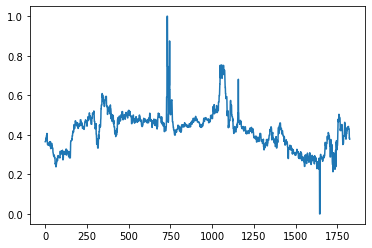

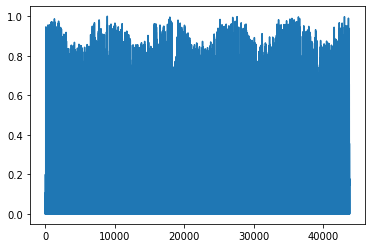

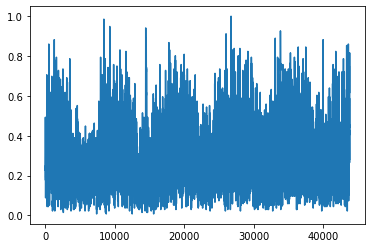

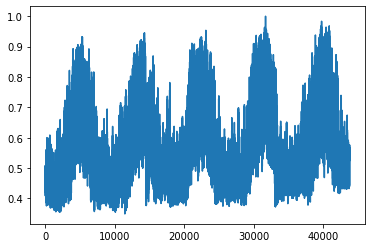

In [13]:
plt.plot(list(case_sl.cost_factor['HO']['CH4'].values()))
plt.show()
plt.plot(list(case_sl.capacity_factor['HO']['PV'].values()))
plt.show()
plt.plot(list(case_sl.capacity_factor['HO']['WF'].values()))
plt.show()
plt.plot(list(case_sl.demand_factor['HO']['Mile'].values()))
plt.show()

In [14]:
reduced_case_sl_d, wcss_sum, rep =  reduce_scenario(
    scenario=case_sl, location=HO, periods=40, scale_level=1, method=Clustermethod.agg_hierarchial,\
        include = ['cost']) #AHC using daily data

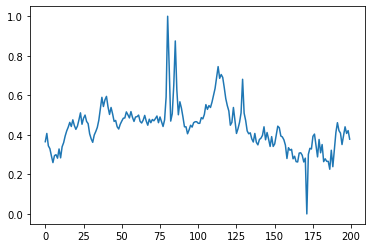

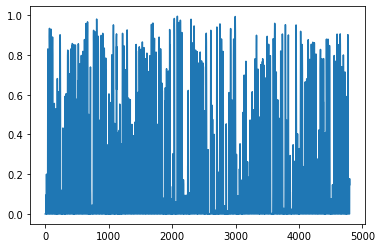

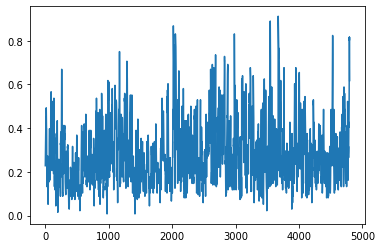

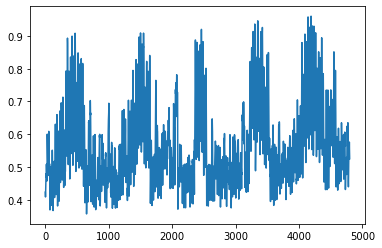

In [15]:
plt.plot(list(reduced_case_sl_d.cost_factor['HO']['CH4'].values()))
plt.show()
plt.plot(list(reduced_case_sl_d.capacity_factor['HO']['PV'].values()))
plt.show()
plt.plot(list(reduced_case_sl_d.capacity_factor['HO']['WF'].values()))
plt.show()
plt.plot(list(reduced_case_sl_d.demand_factor['HO']['Mile'].values()))
plt.show()

In [16]:
reduced_case_sl_h, wcss_sum, rep =  reduce_scenario(
    scenario=case_sl, location=HO, periods=40, scale_level=1, method=Clustermethod.agg_hierarchial,\
        include = ['demand', 'capacity']) #AHC using hourly data

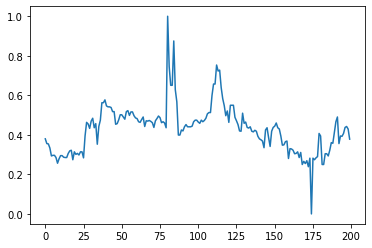

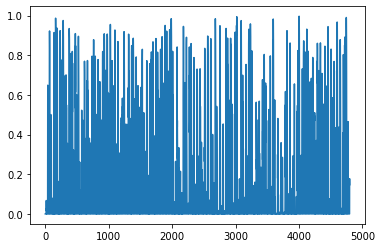

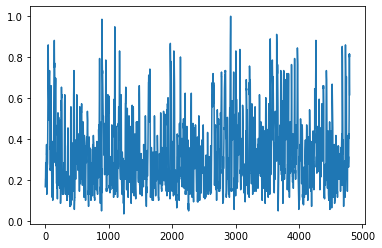

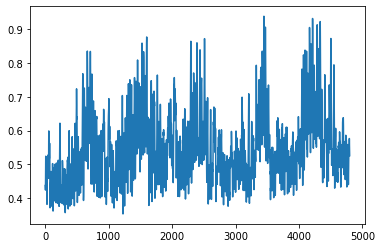

In [17]:
plt.plot(list(reduced_case_sl_h.cost_factor['HO']['CH4'].values()))
plt.show()
plt.plot(list(reduced_case_sl_h.capacity_factor['HO']['PV'].values()))
plt.show()
plt.plot(list(reduced_case_sl_h.capacity_factor['HO']['WF'].values()))
plt.show()
plt.plot(list(reduced_case_sl_h.demand_factor['HO']['Mile'].values()))
plt.show()

$\textbf{Formulate model}$

A pyomo instance is formulated from the scenario

Concises sets and corresponding variables are declared.

Corresponding constraints are generated based on the nature of model chosen

In the presented example, a MILP is formulated



In [19]:
HO_red = Location(name='HO_red', processes= process_set, demand_factor= reduced_case_sl_h.demand_factor['HO'], \
    cost_factor = reduced_case_sl_h.cost_factor['HO'], capacity_factor = reduced_case_sl_h.capacity_factor['HO'], scales=reduced_case_sl_h.scales, \
        label='Houston_red', demand_level=2, capacity_level= 2, cost_level= 1) #sampled for optimal AHC clustering of hourly data

In [20]:
reduced_case_sl = Scenario(name= 'shell', network= HO_red, scales= reduced_case_sl_h.scales,  expenditure_scale_level= 2, scheduling_scale_level= 2, \
    network_scale_level= 0, demand_scale_level= 2, label= 'shell milp case study (HO)')

In [23]:
HO_red1 = Location(name='HO_red1', processes= process_set, demand_factor= reduced_case_sl_h.demand_factor['HO'], \
    cost_factor = reduced_case_sl_d.cost_factor['HO'], capacity_factor = reduced_case_sl_h.capacity_factor['HO'], scales=reduced_case_sl_h.scales, \
        label='Houston_red', demand_level=2, capacity_level= 2, cost_level= 1) #sampled for optimal AHC clustering of daily data

In [22]:
reduced_case_sl2 = Scenario(name= 'shell', network= HO_red, scales= reduced_case_sl_h.scales,  expenditure_scale_level= 2, scheduling_scale_level= 2, \
    network_scale_level= 0, demand_scale_level= 2, label= 'shell milp case study (HO)')

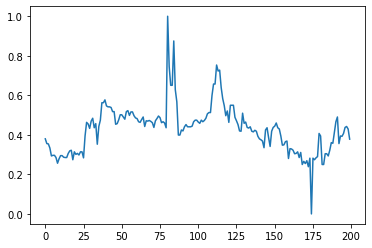

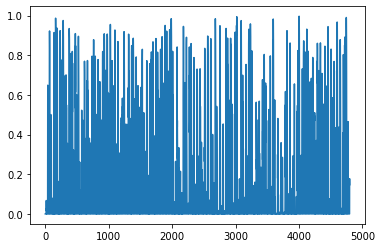

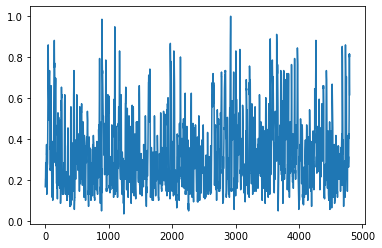

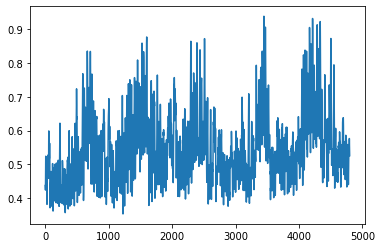

In [24]:
plt.plot(list(reduced_case_sl.cost_factor['HO_red']['CH4'].values()))
plt.show()
plt.plot(list(reduced_case_sl.capacity_factor['HO_red']['PV'].values()))
plt.show()
plt.plot(list(reduced_case_sl.capacity_factor['HO_red']['WF'].values()))
plt.show()
plt.plot(list(reduced_case_sl.demand_factor['HO_red']['Mile'].values()))
plt.show()

Here I try to find a common warped path between hourly sampled and daily sampled data

In [25]:
series1 = list(reduced_case_sl_h.cost_factor['HO']['CH4'].values())
series2 = list(reduced_case_sl_d.cost_factor['HO']['CH4'].values())

In [26]:
mat = dynamic_warping(series1= series1, series2= series2)

In [27]:
path = dynamic_warping_path(mat)

In [28]:
x_ = [path[i][0] for i in range(len(path))]
y_ = [path[i][1] for i in range(len(path))]

In [29]:
x_.reverse()
y_.reverse()

In [30]:
xr = x_[:-1]
yr = y_[:-1]


In [31]:
val1 = [series1[i] for i in xr]
val2 = [series2[i] for i in yr]


In [172]:
# path
# print(val1[167], val2[166])
# print(val1[167], val2[165])
# print(val1[167], val2[164])
# print(val1[167], val2[163])

# print(val1[8], val2[5])
# print(val1[7], val2[5])
# print(val1[6], val2[5])
# print(val1[5], val2[5])


0.25641025641025644 0.25961538461538464
0.2852564102564103 0.25961538461538464
0.29647435897435903 0.25961538461538464
0.29647435897435903 0.25961538461538464


C:\Users\cacodcar\AppData\Local\Temp\ipykernel_17304\3717534732.py:8: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


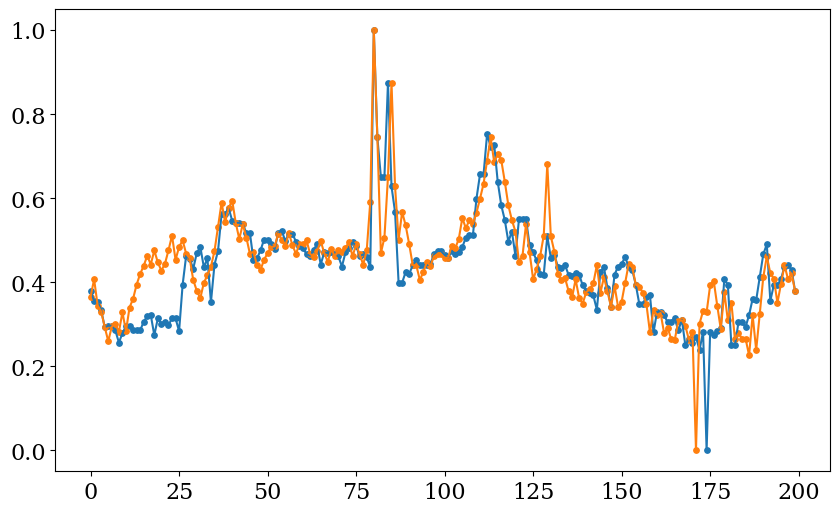

In [33]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 16})
rc('text', usetex=False)
fig, ax = plt.subplots(figsize=(10, 6))
plt.plot(series1)
plt.scatter(list(range(len(series1))), series1, s = 15)
plt.plot(series2)
plt.scatter(list(range(len(series2))), series2, s = 15)
fig.show()
plt.rcdefaults()


C:\Users\cacodcar\AppData\Local\Temp\ipykernel_17304\3869668836.py:8: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


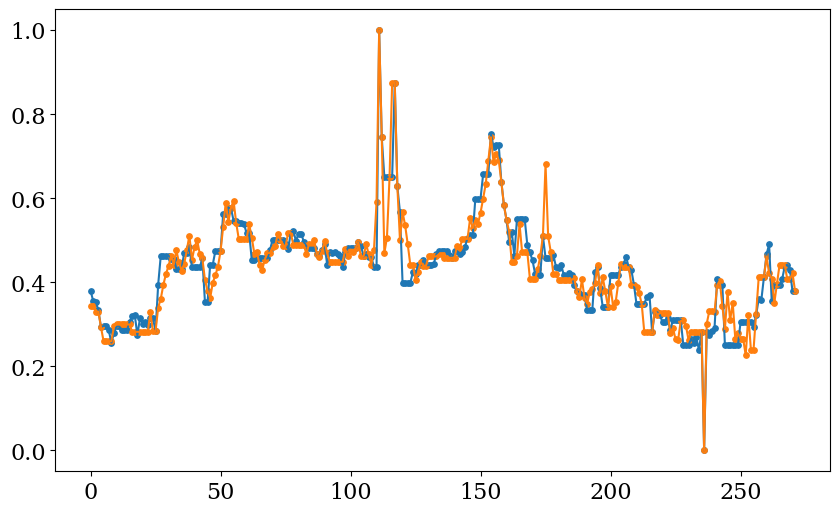

In [35]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 16})
rc('text', usetex=False)
fig, ax = plt.subplots(figsize=(10, 6))
plt.plot(val1)
plt.scatter(list(range(len(val1))), val1, s = 15)
plt.plot(val2)
plt.scatter(list(range(len(val2))), val2, s = 15)
fig.show()
plt.rcdefaults()

C:\Users\cacodcar\AppData\Local\Temp\ipykernel_17304\943757291.py:22: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


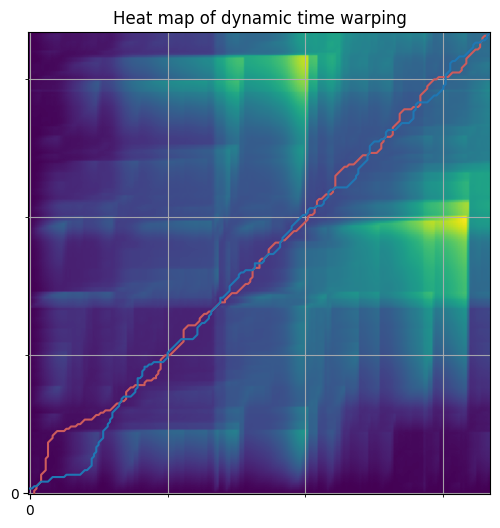

In [36]:
fig, ax = plt.subplots(figsize=(6, 6))

major_ticks = arange(0, len(series1), 300)
minor_ticks = arange(0, len(series2), 60)
ax.set_xticks(major_ticks)
ax.set_xticks(minor_ticks, minor=True)
ax.set_yticks(major_ticks)
ax.set_yticks(minor_ticks, minor=True)
ax.imshow(mat) #, cmap = 'spring')#, interpolation='nearest')
ax.invert_yaxis()
x = [path[i][1] for i in range(len(path))]
y = [path[i][0] for i in range(len(path))]
plt.plot(x,y, color = 'indianred')
plt.plot(x_, y_)
plt.title('Heat map of dynamic time warping')


plt.grid(which = 'minor', alpha=0.9)
plt.grid(which = 'major', alpha=0.9)

# plt.legend()
fig.show()